# Riemannian VAE Frechet

In [1]:
#Modules
import jax.numpy as jnp
import jax.random as jrandom
from jax import vmap, jit

import numpy as np

import haiku as hk

import torch
import torchvision.utils as vutils

import pickle

from abc import ABC

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as tkr

import os

from geometry.riemannian.frechet_mean import GEORCE_FM

from load_manifold import load_manifold
from vae.model_loader import mnist_generator, svhn_generator, celeba_generator, load_model

from vae.models import mnist_encoder
from vae.models import mnist_decoder
from vae.models import mnist_vae

from vae.models import svhn_encoder
from vae.models import svhn_decoder
from vae.models import svhn_vae

from vae.models import celeba_encoder
from vae.models import celeba_decoder
from vae.models import celeba_vae

2025-10-16 19:24:24.044396: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760635464.055597  881962 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760635464.059399  881962 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
plt.rcParams.update({'font.size': 12})
cbformat = tkr.ScalarFormatter()   # create the formatter
cbformat.set_powerlimits((-2,2)) 

In [3]:
seed = 2712
model_path = 'models/'

In [4]:
device = 'gpu'
geometry = "riemannian"
batch_size = '10'
path = f'timing_{device}/{geometry}/'
figure_path = '../figures/vae/frechet/'

In [5]:
if not (os.path.exists(figure_path)):
    os.makedirs(figure_path)

## Loading Values

In [6]:
def load_manifold_data(manifold:str, dim):
    
    save_path = ''.join((path, manifold, '/'))
    
    onlyfiles = [f for f in os.listdir(save_path) if os.path.isfile(os.path.join(save_path, f))]
    onlyfiles = [f for f in onlyfiles if f'batch={batch_size}.pkl' in f]
    
    estimates = {}
    for file in onlyfiles:
        file_path = ''.join((save_path, file))
        with open(file_path, 'rb') as f:
            values = pickle.load(f)
        method = file.split(f'_{manifold}')[0]
        dim = file.replace(f"{method}_", '').replace(manifold, '').replace('.pkl', '').replace('_d=', '').replace(f'_batch={batch_size}', '')
        if dim in estimates:
            estimates[dim] = dict(estimates[dim], **values)
        else:
            estimates[dim] = values
            
    return estimates
    

## VAE MNIST

In [7]:
latent_dim = 8

### Loading Data

In [8]:
mnist_dataloader = mnist_generator(seed=2712,
                                   batch_size=64,
                                   split='train[:80%]')

I0000 00:00:1751829865.391731   98802 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2611 MB memory:  -> device: 0, name: NVIDIA T1200 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 7.5
W0000 00:00:1751829865.503258   98931 gpu_backend_lib.cc:579] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykern/cuda_nvcc
  
  /usr/local/cuda
  /home/fmry/anaconda3/lib/python3.12/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /home/fmry/anaconda3/lib/python3.12/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  /home/fmry/anaconda3/lib/python3.12/site-packages/tensorflow/python/platform/../../cuda
  .
You can choose the search directory by setting xla_gpu_cuda_data_dir in HloModul

In [9]:
mnist_method = load_manifold_data("mnist", dim=latent_dim)[str(latent_dim)]

/tmp/ipykernel_98802/4274572303.py:12: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  values = pickle.load(f)


In [10]:
mnist_zobs, M_mnist, *_ = load_manifold("mnist", dim=latent_dim, N_data=10)

In [11]:
mnist_zmu = mnist_method['GEORCE_FM']['mu']
mnist_zgeodesics = mnist_method['GEORCE_FM']['zt'][:,::-1]

In [12]:
mnist_xobs = vmap(M_mnist.f)(mnist_zobs)
mnist_xmu = M_mnist.f(mnist_zmu)
mnist_xgeodesics = vmap(vmap(M_mnist.f))(mnist_zgeodesics)

### Loading Model

In [13]:
@hk.transform
def mnist_tvae(x):


    vae = mnist_vae(
                encoder=mnist_encoder(latent_dim=latent_dim),
                decoder=mnist_decoder(),
    )

    return vae(x)

@hk.transform
def mnist_tencoder(x):


    encoder = mnist_encoder(latent_dim=latent_dim)

    return encoder(x)[0]

@hk.transform
def mnist_tdecoder(x):

    decoder = mnist_decoder()

    return decoder(x)

In [14]:
mnist_state = load_model(''.join((model_path, f'mnist_{latent_dim}/')))

In [15]:
mnist_encoder_fun = lambda x: mnist_tencoder.apply(mnist_state.params, None, x.reshape(-1,
                                                                                       28,
                                                                                       28,
                                                                                       1)).reshape(-1,
                                                                                                   latent_dim).squeeze()
mnist_decoder_fun = lambda x: mnist_tdecoder.apply(mnist_state.params, None, x.reshape(-1,
                                                                                       latent_dim)).reshape(-1,
                                                                                                            28*28).squeeze()
mnist_vae_fun = lambda x: mnist_tvae.apply(mnist_state.params, mnist_state.rng_key, x)

In [16]:
mnist_data = next(mnist_dataloader).x

### Plotting Reconstruction

In [17]:
mnist_data = next(mnist_dataloader).x

In [18]:
mnist_rec = mnist_vae_fun(mnist_data)

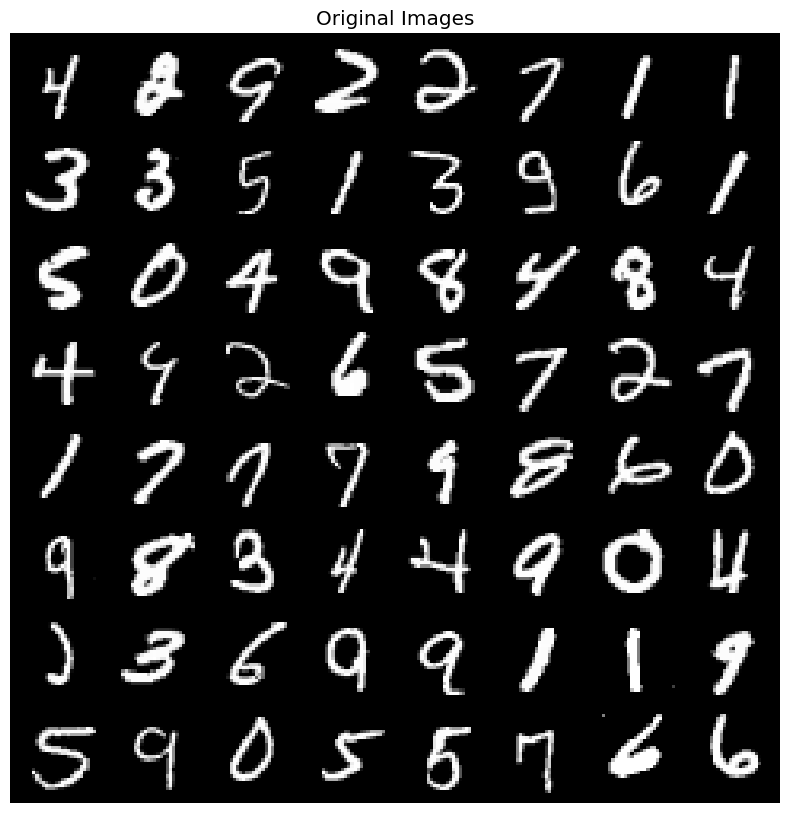

In [19]:
plot_val = torch.from_numpy(np.transpose(np.array(mnist_data), (0,3,1,2)))
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_axis_off()
ax.set_title("Original Images")
ax.imshow(np.transpose(vutils.make_grid(plot_val, padding=2, normalize=True).cpu(),(1,2,0)))

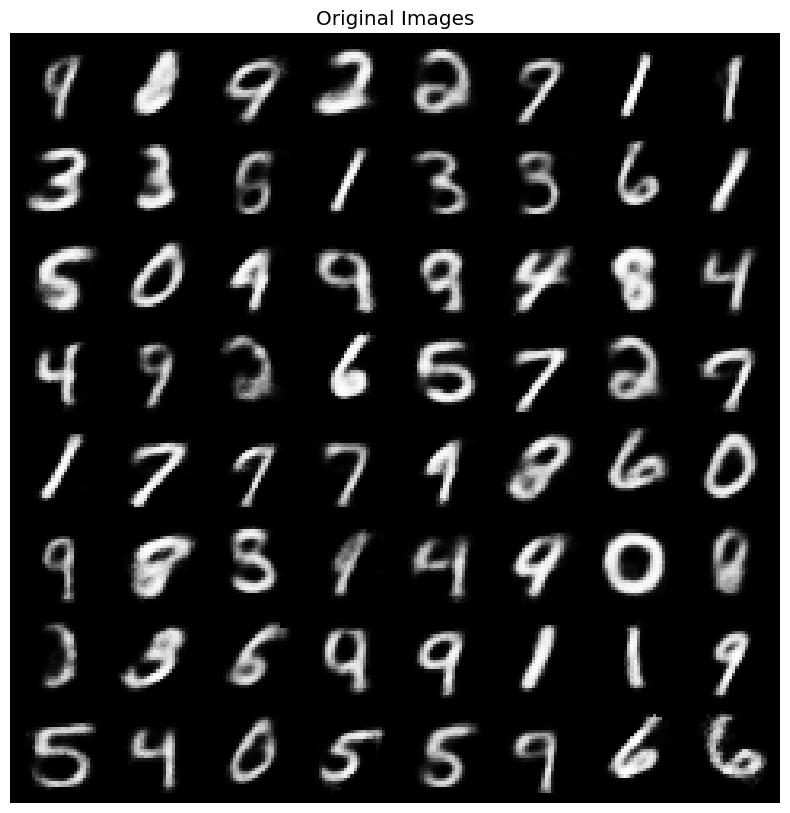

In [20]:
plot_val = torch.from_numpy(np.transpose(np.array(mnist_rec.mu_xz), (0,3,1,2)))
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_axis_off()
ax.set_title("Original Images")
ax.imshow(np.transpose(vutils.make_grid(plot_val, padding=2, normalize=True).cpu(),(1,2,0)))

### Plotting

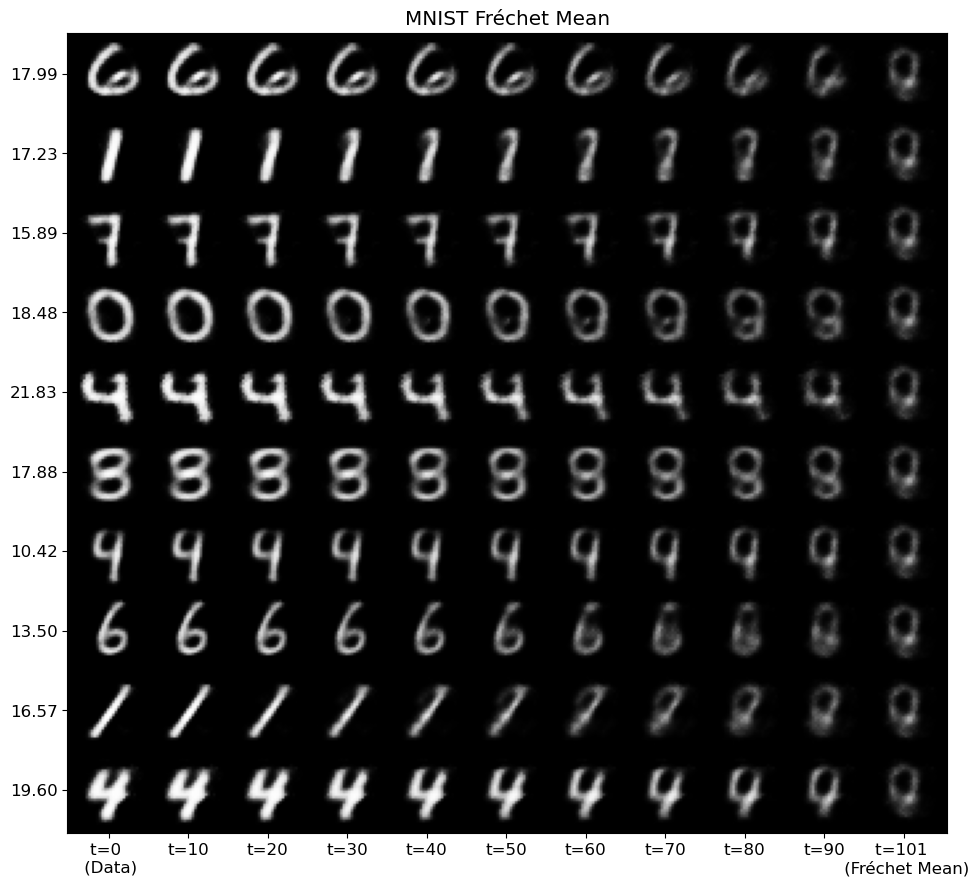

In [21]:
img_height = 28+2
plot_grid = (mnist_xgeodesics.shape[1]+1)//10
tick_list = [img_height/2+j*img_height for j in range(len(mnist_xgeodesics))]
xt = jnp.stack([jnp.vstack((obs, geo[::plot_grid][:-1], mnist_xmu)) for obs, geo in zip(mnist_xobs, mnist_xgeodesics)])
length = [f"{M_mnist.length(jnp.vstack((mnist_zmu, geo, obs))):.2f}" for obs, geo in zip(mnist_zobs, mnist_zgeodesics)]

tick_xlist = [img_height/2+j*img_height for j in range(len(mnist_xgeodesics)+1)]
grid_index = [f"t={int(plot_grid*i)}" for i in range(len(mnist_xgeodesics))]
grid_index[0] = f"t={int(plot_grid*0)} \n (Data)"
grid_index.append(f"t={mnist_xgeodesics.shape[1]+2} \n (Fréchet Mean)")

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_title(f"MNIST Fréchet Mean")
plot_val = torch.from_numpy(np.transpose(np.array(xt.reshape(-1,28,28,1)), (0,3,1,2)))
ax.imshow(vutils.make_grid(plot_val, padding=2, normalize=True, nrow=plot_grid+1).permute(1, 2, 0))

ax.set_yticks(tick_list)
ax.set_yticklabels(length)

ax.set_xticks(tick_xlist)
ax.set_xticklabels(grid_index)

fig.tight_layout()

plt.show()

save_path = f'{figure_path}mnist_{geometry}_{latent_dim}.pdf'
fig.savefig(save_path, format='pdf', pad_inches=0.1, bbox_inches='tight')

#for x in xt:
#    plot_val = torch.from_numpy(np.transpose(np.array(x.reshape(-1,28,28,1)), (0,3,1,2)))
#    ax.imshow(vutils.make_grid(plot_val, padding=2, normalize=True, nrow=plot_grid+1).permute(1, 2, 0))

## VAE SVHN

In [22]:
latent_dim = 32

### Loading Data

In [23]:
svhn_dataloader = svhn_generator(data_dir="../../../Data/SVHN/",
                                 batch_size=64,
                                 seed=2712,
                                 split='train[:80%]')

In [24]:
svhn_method = load_manifold_data("svhn", dim=latent_dim)[str(latent_dim)]

FileNotFoundError: [Errno 2] No such file or directory: 'timing_gpu/riemannian/svhn/'

In [ ]:
svhn_zobs, M_svhn, *_ = load_manifold("svhn", dim=latent_dim, N_data=10)

In [ ]:
svhn_zmu = svhn_method['GEORCE_FM']['mu']
svhn_zgeodesics = svhn_method['GEORCE_FM']['zt'][:,::-1]

In [ ]:
svhn_xobs = vmap(M_svhn.f)(svhn_zobs)
svhn_xmu = M_svhn.f(svhn_zmu)
svhn_xgeodesics = vmap(vmap(M_svhn.f))(svhn_zgeodesics)

### Loading Model

In [ ]:
@hk.transform
def svhn_tvae(x):


    vae = svhn_vae(
                encoder=svhn_encoder(latent_dim=latent_dim),
                decoder=svhn_decoder(),
    )

    return vae(x)

@hk.transform_with_state
def svhn_tencoder(x):


    encoder = svhn_encoder(latent_dim=latent_dim)

    return encoder(x)

@hk.transform_with_state
def svhn_tdecoder(x):

    decoder = svhn_decoder(latent_dim=latent_dim)

    return decoder(x)

In [ ]:
svhn_state = load_model(''.join((model_path, f'svhn_{latent_dim}/')))

In [ ]:
svhn_encoder_fun = lambda x: svhn_tencoder.apply(svhn_state.params, svhn_state.rng_key, x)
svhn_decoder_fun = lambda x: svhn_tdecoder.apply(svhn_state.params, svhn_state.rng_key, x)
svhn_vae_fun = lambda x: svhn_tvae.apply(svhn_state.params, svhn_state.rng_key, x)

### Plotting Reconstruction

In [ ]:
svhn_data = next(svhn_dataloader).x

In [ ]:
svhn_rec = svhn_vae_fun(svhn_data)

In [ ]:
plot_val = torch.from_numpy(np.transpose(np.array(svhn_data), (0,3,1,2)))
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_axis_off()
ax.set_title("Original Images")
ax.imshow(np.transpose(vutils.make_grid(plot_val, padding=2, normalize=True).cpu(),(1,2,0)))

In [ ]:
plot_val = torch.from_numpy(np.transpose(np.array(svhn_rec.mu_xz), (0,3,1,2)))
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_axis_off()
ax.set_title("Original Images")
ax.imshow(np.transpose(vutils.make_grid(plot_val, padding=2, normalize=True).cpu(),(1,2,0)))

### Plotting

In [ ]:
img_height = 32+2
plot_grid = (svhn_xgeodesics.shape[1]+1)//10
tick_list = [img_height/2+j*img_height for j in range(len(svhn_xgeodesics))]
xt = jnp.stack([jnp.vstack((obs, geo[::plot_grid][:-1], svhn_xmu)) for obs, geo in zip(svhn_xobs, svhn_xgeodesics)])
length = [f"Length: {M_svhn.length(jnp.vstack((svhn_zmu, geo, obs))):.2f}" for obs, geo in zip(svhn_zobs, svhn_zgeodesics)]

tick_xlist = [img_height/2+j*img_height for j in range(len(svhn_xgeodesics)+1)]
grid_index = [f"t={int(plot_grid*i)}" for i in range(len(svhn_xgeodesics))]
grid_index[0] = f"t={int(plot_grid*0)} \n (Data)"
grid_index.append(f"t={svhn_xgeodesics.shape[1]+2} \n (Fréchet Mean)")

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_title(f"SVHN Fréchet Mean")
plot_val = torch.from_numpy(np.transpose(np.array(xt.reshape(-1,32,32,3)), (0,3,1,2)))
ax.imshow(vutils.make_grid(plot_val, padding=2, normalize=True, nrow=plot_grid+1).permute(1, 2, 0))

ax.set_yticks(tick_list)
ax.set_yticklabels(length)

ax.set_xticks(tick_xlist)
ax.set_xticklabels(grid_index)

fig.tight_layout()

plt.show()

save_path = f'{figure_path}svhn_{geometry}_{latent_dim}.pdf'
fig.savefig(save_path, format='pdf', pad_inches=0.1, bbox_inches='tight')

## VAE CelebA

In [25]:
latent_dim = 32

### Loading Data

In [26]:
celeba_dataloader = celeba_generator(data_dir="../../../Data/CelebA/",
                                     batch_size=64,
                                     seed=2712, 
                                     split=0.8)

In [27]:
celeba_method = load_manifold_data("celeba", dim=latent_dim)[str(latent_dim)]

/tmp/ipykernel_98802/4274572303.py:12: DeprecationWarning: Pickled array contains an aval with a named_shape attribute. This is deprecated and the code path supporting such avals will be removed. Please re-pickle the array.
  values = pickle.load(f)


In [28]:
celeba_zobs, M_celeba, *_ = load_manifold("celeba", dim=latent_dim, N_data=10)

In [29]:
celeba_zmu = celeba_method['GEORCE_FM']['mu']
celeba_zgeodesics = celeba_method['GEORCE_FM']['zt'][:,::-1]

In [30]:
celeba_xobs = vmap(M_celeba.f)(celeba_zobs)
celeba_xmu = M_celeba.f(celeba_zmu)
celeba_xgeodesics = vmap(vmap(M_celeba.f))(celeba_zgeodesics)

### Loading Model

In [31]:
@hk.transform
def celeba_tvae(x):


    vae = celeba_vae(
                encoder=celeba_encoder(latent_dim=latent_dim),
                decoder=celeba_decoder(),
    )

    return vae(x)

@hk.transform
def celeba_tencoder(x):


    encoder = celeba_encoder(latent_dim=latent_dim)

    return encoder(x)

@hk.transform
def celeba_tdecoder(x):

    decoder = celeba_decoder(latent_dim=latent_dim)

    return decoder(x)

In [32]:
celeba_state = load_model(''.join((model_path, f'celeba_{latent_dim}/')))

In [33]:
celeba_encoder_fun = lambda x: celeba_tencoder.apply(celeba_state.params, celeba_state.rng_key, x)
celeba_decoder_fun = lambda x: celeba_tdecoder.apply(celeba_state.params, celeba_state.rng_key, x)
celeba_vae_fun = lambda x: celeba_tvae.apply(celeba_state.params, celeba_state.rng_key, x)

### Plotting Reconstruction

In [34]:
celeba_data = next(celeba_dataloader).x

In [35]:
celeba_rec = celeba_vae_fun(celeba_data)

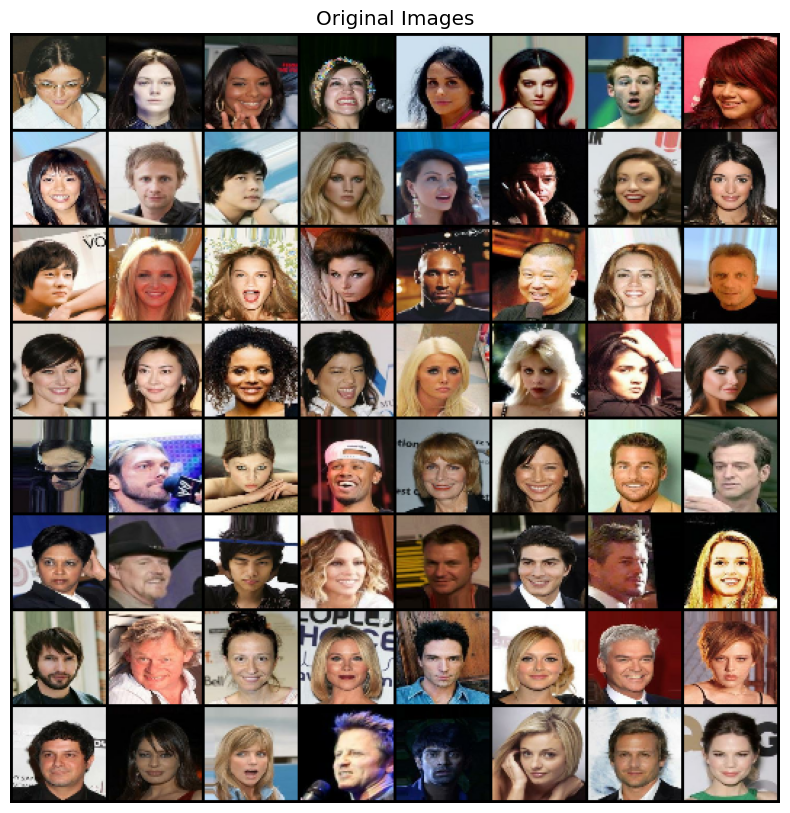

In [36]:
plot_val = torch.from_numpy(np.transpose(np.array(celeba_data), (0,3,1,2)))
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_axis_off()
ax.set_title("Original Images")
ax.imshow(np.transpose(vutils.make_grid(plot_val, padding=2, normalize=True).cpu(),(1,2,0)))

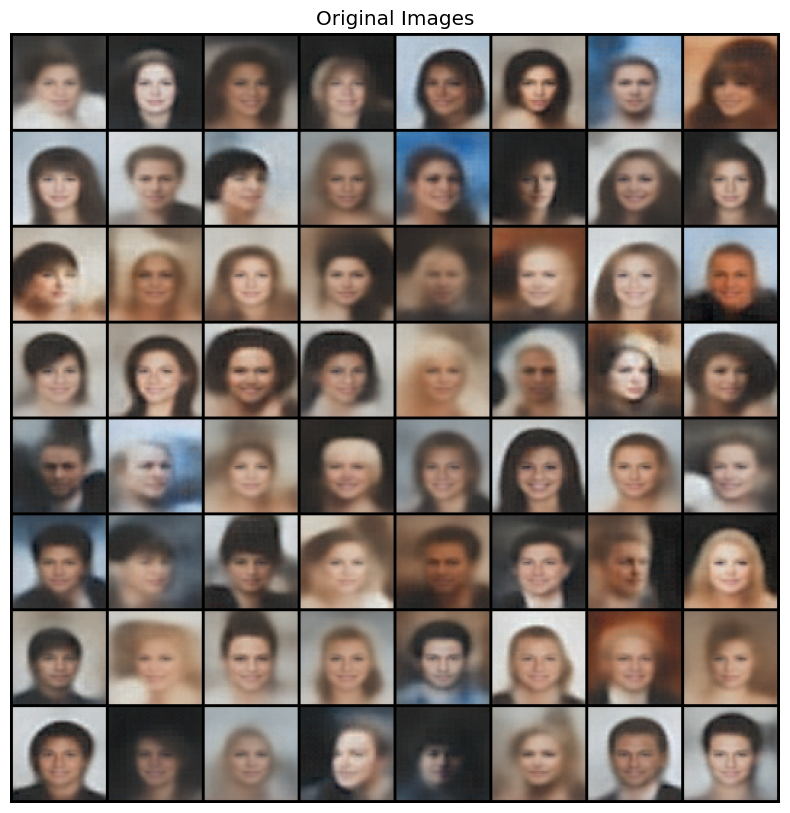

In [37]:
plot_val = torch.from_numpy(np.transpose(np.array(celeba_rec.mu_xz), (0,3,1,2)))
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_axis_off()
ax.set_title("Original Images")
ax.imshow(np.transpose(vutils.make_grid(plot_val, padding=2, normalize=True).cpu(),(1,2,0)))

### Plotting

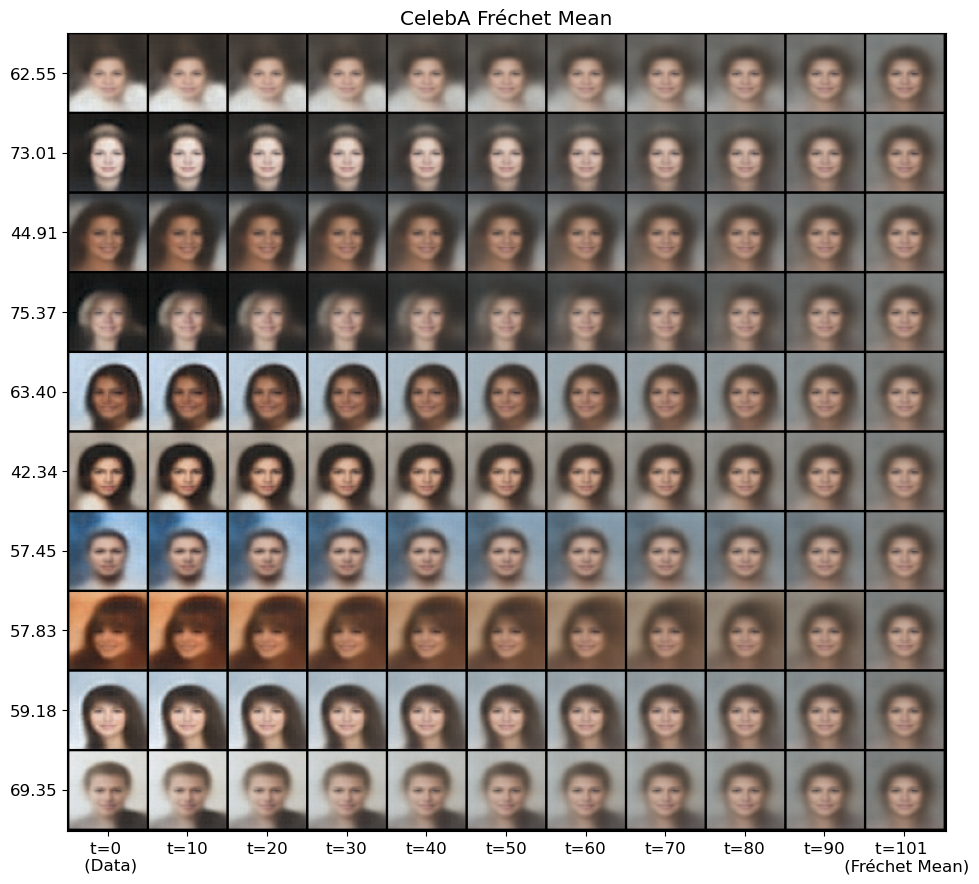

In [38]:
img_height = 64+2
plot_grid = (celeba_xgeodesics.shape[1]+1)//10
tick_list = [img_height/2+j*img_height for j in range(len(celeba_xgeodesics))]
xt = jnp.stack([jnp.vstack((obs, geo[::plot_grid][:-1], celeba_xmu)) for obs, geo in zip(celeba_xobs, celeba_xgeodesics)])
length = [f"{M_celeba.length(jnp.vstack((celeba_zmu, geo, obs))):.2f}" for obs, geo in zip(celeba_zobs, celeba_zgeodesics)]

tick_xlist = [img_height/2+j*img_height for j in range(len(celeba_xgeodesics)+1)]
grid_index = [f"t={int(plot_grid*i)}" for i in range(len(celeba_xgeodesics))]
grid_index[0] = f"t={int(plot_grid*0)} \n (Data)"
grid_index.append(f"t={celeba_xgeodesics.shape[1]+2} \n (Fréchet Mean)")

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_title(f"CelebA Fréchet Mean")
plot_val = torch.from_numpy(np.transpose(np.array(xt.reshape(-1,64,64,3)), (0,3,1,2)))
ax.imshow(vutils.make_grid(plot_val, padding=2, normalize=True, nrow=plot_grid+1).permute(1, 2, 0))

ax.set_yticks(tick_list)
ax.set_yticklabels(length)

ax.set_xticks(tick_xlist)
ax.set_xticklabels(grid_index)

fig.tight_layout()

plt.show()

save_path = f'{figure_path}celeba_{geometry}_{latent_dim}.pdf'
fig.savefig(save_path, format='pdf', pad_inches=0.1, bbox_inches='tight')

### Principal Geodesic Analysis

In [39]:
_, M, *_ = load_manifold("celeba", dim=32)

In [40]:
n_components = 3
n_samples = 3

In [41]:
u0 = celeba_zgeodesics[:,1]-celeba_zgeodesics[:,0]

In [42]:
pga_S = jnp.mean(jnp.einsum('...i,...j->...ij', u0, u0), axis=0)

In [43]:
U, S, V = jnp.linalg.svd(pga_S)

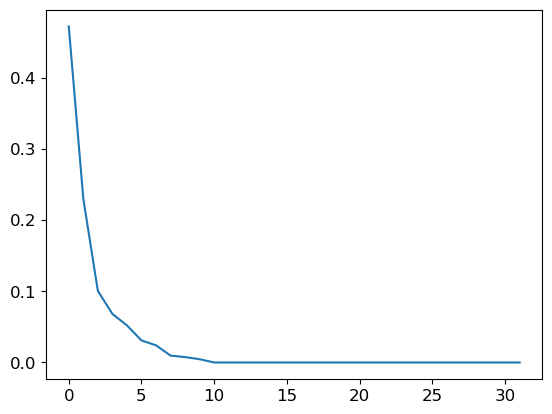

In [46]:
plt.plot(S*S/(S*S).sum())

In [47]:
jnp.cumsum(S*S/(S*S).sum())

Array([0.47213945, 0.7022216 , 0.80282336, 0.87105536, 0.9231828 ,
       0.9541185 , 0.97819114, 0.9878579 , 0.99540734, 1.0000001 ,
       1.0000001 , 1.0000001 , 1.0000001 , 1.0000001 , 1.0000001 ,
       1.0000001 , 1.0000001 , 1.0000001 , 1.0000001 , 1.0000001 ,
       1.0000001 , 1.0000001 , 1.0000001 , 1.0000001 , 1.0000001 ,
       1.0000001 , 1.0000001 , 1.0000001 , 1.0000001 , 1.0000001 ,
       1.0000001 , 1.0000001 ], dtype=float32)

In [48]:
principal_zgeo = jnp.stack([M.Exp(celeba_zmu, v) for v in V[:n_components]])

In [49]:
principal_xgeo = vmap(vmap(M.f))(principal_zgeo)

In [50]:
coef = jnp.array(np.random.normal(size=(n_samples*n_components,))).reshape(-1,n_components)
principal_xsamples = vmap(vmap(M.f))(jnp.stack([M.Exp(celeba_zmu, jnp.einsum('i,ij->j', c, V[:n_components])) for c in coef]))

6


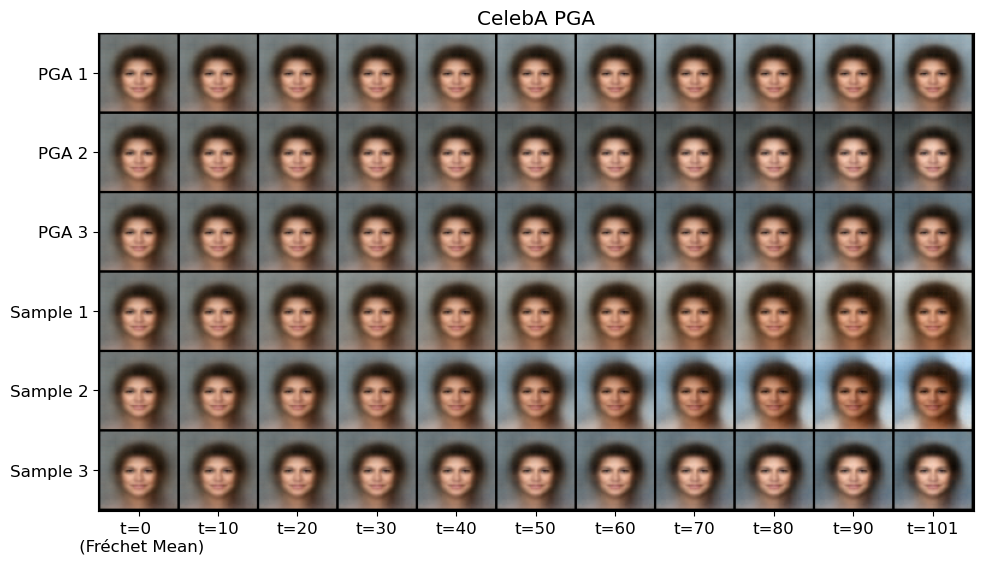

In [53]:
img_height = 64+2
plot_grid = (principal_xgeo.shape[1]+1)//10
tick_list = [img_height/2+j*img_height for j in range(len(principal_xgeo))]
xt = jnp.stack([x[::plot_grid] for x in principal_xgeo])
xt = jnp.concatenate((xt, principal_xsamples[:,::plot_grid].reshape(3,-1,64*64*3)), axis=0)

tick_list = [img_height/2+j*img_height for j in range(len(principal_xgeo)+len(principal_xsamples))]
tick_xlist = [img_height/2+j*img_height for j in range(plot_grid+1)]
name1 = [f"PGA {i}" for i in range(1, len(principal_xgeo)+1)]
name2 = [f"Sample {i}" for i in range(1, len(principal_xsamples)+1)]
names = name1+name2
grid_index = [f"t={int(plot_grid*i)}" for i in range(plot_grid)]
grid_index[0] = f"t={int(plot_grid*0)} \n (Fréchet Mean)"
grid_index.append(f"t={principal_xgeo.shape[1]}")

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.set_title(f"CelebA PGA")
plot_val = torch.from_numpy(np.transpose(np.array(xt.reshape(-1,64,64,3)), (0,3,1,2)))
ax.imshow(vutils.make_grid(plot_val, padding=2, normalize=True, nrow=plot_grid+1).permute(1, 2, 0))

print(len(tick_list))
ax.set_yticks(tick_list)
ax.set_yticklabels(names)

ax.set_xticks(tick_xlist)
ax.set_xticklabels(grid_index)

fig.tight_layout()

plt.show()

save_path = f'{figure_path}celeba_pga_{geometry}_{latent_dim}.pdf'
fig.savefig(save_path, format='pdf', pad_inches=0.1, bbox_inches='tight')